## 1. Setup do ambiente e clone do repositório

In [2]:
# Verifica GPU disponível
!nvidia-smi

Wed Jul  8 19:19:44 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX PRO 6000 Blac...    Off |   00000000:05:00.0 Off |                    0 |
| N/A   27C    P0             47W /  600W |       0MiB /  97887MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [3]:
%cd /content
!git clone https://github.com/spinnerf3d/SPIn-NeRF.git
%cd SPIn-NeRF

/content
fatal: destination path 'SPIn-NeRF' already exists and is not an empty directory.
/content/SPIn-NeRF


O `requirements.txt` do repo original é antigo (pensado para PyTorch/CUDA de 2022-2023). Instalamos primeiro o PyTorch compatível com a GPU do Colab, e só depois o resto — isso evita que o pip tente rebaixar o torch já instalado no runtime.

Se algum pacote falhar por incompatibilidade, rode a célula de novo — normalmente o pip resolve na segunda tentativa ignorando o conflito de versão que já foi satisfeito.

In [4]:
# PyTorch (ajuste o índice de CUDA se o Colab tiver mudado a versão padrão)
!pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

# Dependências do SPIn-NeRF (DS_NeRF), sem os pins antigos e sem o módulo MVSeg opcional
!pip install -q imageio imageio-ffmpeg matplotlib configargparse tensorboard \
    opencv-python mediapy numpy lpips scikit-video ffmpeg-python pytorch-ignite

# CLIP (usado por alguns módulos do repo, leve e sem problema de build)
!pip install -q git+https://github.com/openai/CLIP.git

# Dependências do LaMa (inpainting 2D), sem os pins antigos
!pip install -q pyyaml tqdm numpy easydict scikit-image scikit-learn opencv-python tensorflow joblib matplotlib pandas albumentations hydra-core pytorch-lightning tabulate kornia webdataset packaging wldhx.yadisk-direct
!pip install -q gdown

# Só rode isto se algum script pedir tiny-cuda-nn ou reclamar de kornia incompatível
!pip install -q ninja
!pip install -q git+https://github.com/NVlabs/tiny-cuda-nn/#subdirectory=bindings/torch

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done


## 2. Preparo do dataset e reconstrução COLMAP



```
data/<sua_cena>/
├── images/
│   ├── IMG_0001.jpg
│   ├── IMG_0002.jpg
│   └── ...
```



In [5]:
!apt-get install -y colmap
!colmap -h  # confirma que instalou

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
colmap is already the newest version (3.7-2).
0 upgraded, 0 newly installed, 0 to remove and 53 not upgraded.
COLMAP 3.7 -- Structure-from-Motion and Multi-View Stereo
              (Commit Unknown on Unknown without CUDA)

Usage:
  colmap [command] [options]

Documentation:
  https://colmap.github.io/

Example usage:
  colmap help [ -h, --help ]
  colmap gui
  colmap gui -h [ --help ]
  colmap automatic_reconstructor -h [ --help ]
  colmap automatic_reconstructor --image_path IMAGES --workspace_path WORKSPACE
  colmap feature_extractor --image_path IMAGES --database_path DATABASE
  colmap exhaustive_matcher --database_path DATABASE
  colmap mapper --image_path IMAGES --database_path DATABASE --output_path MODEL
  ...

Available commands:
  help
  gui
  automatic_reconstructor
  bundle_adjuster
  color_extractor
  database_cleaner
  database_creator
  database_merger
  delaunay_mesher
  exh

In [6]:
import shutil, os

SCENE_NAME = "statue"
SCENE_DIR = "/content/data"          # <-- caminho único usado em TODO o notebook
INPUT_DIR = f"{SCENE_DIR}/input"
os.makedirs(INPUT_DIR, exist_ok=True)

# Se as imagens já estiverem organizadas em subpastas dentro de INPUT_DIR
# (ex.: vindas do Drive), este bloco as achata numa única pasta.
if os.path.isdir(INPUT_DIR):
    subpastas = [d for d in os.listdir(INPUT_DIR) if os.path.isdir(os.path.join(INPUT_DIR, d))]
    total = 0
    for subpasta in subpastas:
        subpasta_path = os.path.join(INPUT_DIR, subpasta)
        for fname in sorted(os.listdir(subpasta_path)):
            ext = os.path.splitext(fname)[1].lower()
            if ext not in [".jpg", ".jpeg", ".png"]:
                continue
            novo_nome = f"{subpasta}_{fname}"
            shutil.copy(
                os.path.join(subpasta_path, fname),
                os.path.join(INPUT_DIR, novo_nome)
            )
            total += 1
    print(f"{total} imagens organizadas em {INPUT_DIR}")

0 imagens organizadas em /content/data/input


In [7]:
# 1. Extraia as features das imagens (pontos chave e descritores)
!colmap feature_extractor \
    --database_path {SCENE_DIR}/database.db \
    --image_path {SCENE_DIR}/input \
    --ImageReader.camera_model SIMPLE_PINHOLE \
    --SiftExtraction.use_gpu 0


Feature extraction

Elapsed time: 0.000 [minutes]


In [8]:
# 2. Encontre correspondências entre as features de todas as imagens
!colmap exhaustive_matcher \
    --database_path {SCENE_DIR}/database.db \
    --SiftMatching.use_gpu 0


Exhaustive feature matching

Matching block [1/1, 1/1] in 0.002s
Elapsed time: 0.000 [minutes]


In [9]:
# 3. Reconstrua a cena 3D e estime as poses das câmeras
!mkdir -p {SCENE_DIR}/sparse
!colmap mapper \
    --database_path {SCENE_DIR}/database.db \
    --image_path {SCENE_DIR}/input \
    --output_path {SCENE_DIR}/sparse


Loading database

Loading cameras... 1 in 0.000s
Loading matches... 204 in 0.001s
Loading images... 33 in 0.008s (connected 33)
Building correspondence graph... in 0.012s (ignored 0)

Elapsed time: 0.000 [minutes]


Finding good initial image pair


Initializing with image pair #10 and #4


Global bundle adjustment

iter      cost      cost_change  |gradient|   |step|    tr_ratio  tr_radius  ls_iter  iter_time  total_time
   0  1.463311e+03    0.00e+00    1.30e+05   0.00e+00   0.00e+00  1.00e+04        0    3.28e-04    1.00e-03
   1  3.304189e+02    1.13e+03    6.00e+04   4.59e+01   9.61e-01  3.00e+04        1    5.86e-04    1.60e-03
   2  2.635444e+02    6.69e+01    1.54e+04   3.35e+00   8.31e-01  4.22e+04        1    5.05e-04    2.12e-03
   3  2.436297e+02    1.99e+01    8.54e+03   1.40e+01   8.84e-01  7.75e+04        1    5.10e-04    2.63e-03
   4  2.390191e+02    4.61e+00    3.99e+03   1.01e+01   9.08e-01  1.70e+05        1    5.02e-04    3.14e-03
   5  2.382602e+02    7.59e-01   

In [10]:
import os, shutil

input_dir = os.path.join(SCENE_DIR, 'input')
images_dir = os.path.join(SCENE_DIR, 'images')
os.makedirs(images_dir, exist_ok=True)

num_moved = 0
for fname in os.listdir(input_dir):
    if fname.lower().endswith(('.png', '.jpg', '.jpeg')):
        shutil.move(os.path.join(input_dir, fname), os.path.join(images_dir, fname))
        num_moved += 1

print(f"Moved {num_moved} image files from {input_dir} to {images_dir}")

Moved 0 image files from /content/data/input to /content/data/images


 Geração de `poses_bounds.npy`



In [11]:
%cd /content/SPIn-NeRF

!python imgs2poses.py --data_dir {SCENE_DIR}

import os
assert os.path.exists(f"{SCENE_DIR}/poses_bounds.npy"), \
    "poses_bounds.npy não foi gerado — confira o log do imgs2poses.py acima"
print("poses_bounds.npy gerado com sucesso em", SCENE_DIR)

Streaming output truncated to the last 5000 lines.
9
21
12
9
21
12
9
21
12
9
21
12
9
21
12
9
19
27
12
9
21
12
9
21
19
27
12
9
27
13
12
9
21
3
19
27
12
9
21
12
9
21
12
9
21
27
12
9
19
12
9
21
19
27
12
9
21
12
9
21
19
27
12
9
21
3
12
9
21
19
12
9
21
12
9
21
19
12
9
21
19
27
12
9
21
12
9
21
12
9
21
12
9
21
19
27
12
9
21
19
12
9
21
12
9
21
12
9
21
12
9
19
12
9
21
12
9
21
12
21
19
12
21
12
21
12
21
12
21
12
21
19
12
9
21
12
9
21
12
21
19
12
9
21
12
9
21
12
9
21
12
9
21
12
9
21
12
9
21
12
9
21
19
27
12
9
21
12
9
12
9
21
12
9
21
12
9
21
12
9
21
12
9
21
12
9
21
12
9
21
12
9
21
19
12
9
21
12
9
21
12
9
21
12
9
21
19
12
9
21
12
9
21
12
9
21
12
9
21
12
9
21
12
9
21
12
9
21
19
27
13
32
12
9
21
12
9
21
12
9
21
12
9
21
12
9
21
19
27
12
9
21
27
12
9
21
19
27
12
9
21
19
12
9
21
12
9
21
12
9
21
12
9
21
12
9
21
12
9
21
12
9
21
12
9
21
12
9
21
19
12
9
21
27
12
9
21
12
9
21
27
12
9
21
27
19
12
9
21
12
9
21
12
9
21
19
12
9
21
19
12
9
21
12
9
21
19
12
9
21
19
12
9
21
12
9
21
19
27
13
32
33
12
9
21
12
9
19
27

## 3. Segmentação multivista (DEVA + Grounded-SAM)

In [12]:
%cd /content
!git clone https://github.com/hkchengrex/Tracking-Anything-with-DEVA.git
%cd Tracking-Anything-with-DEVA
!pip install -e .
!bash scripts/download_models.sh

!git clone https://github.com/hkchengrex/Grounded-Segment-Anything.git
%cd Grounded-Segment-Anything
import os
os.environ["AM_I_DOCKER"] = "False"
os.environ["BUILD_WITH_CUDA"] = "True"
os.environ["CUDA_HOME"] = "/usr/local/cuda"
!python -m pip install -e segment_anything
!python -m pip install -e GroundingDINO
%cd /content

/content
fatal: destination path 'Tracking-Anything-with-DEVA' already exists and is not an empty directory.
/content/Tracking-Anything-with-DEVA
Obtaining file:///content/Tracking-Anything-with-DEVA
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Installing backend dependencies ... done
  Preparing editable metadata (pyproject.toml) ... done
  Cloning https://github.com/cheind/py-thin-plate-spline to /tmp/pip-install-7kcuuosu/thinplate_6759bfeeeb41435dba7173f31bd06a04
  Running command git clone --filter=blob:none --quiet https://github.com/cheind/py-thin-plate-spline /tmp/pip-install-7kcuuosu/thinplate_6759bfeeeb41435dba7173f31bd06a04
  Resolved https://github.com/cheind/py-thin-plate-spline to commit f6995795397118b7d0ac01aecd3f39ffbfad9dee
  Preparing metadata (setup.py) ... done
  Building editable for deva (pyproject.toml) ... done
  Created wheel for deva: filename=deva-1.0.

A versão instalada do pacote `supervision` mudou a API de anotação (`BoxAnnotator` / `LabelAnnotator` separados). O patch abaixo ajusta `eval_args.py` para a API nova. Ele é idempotente — se a string já foi trocada (ex.: rerun), ele avisa e não faz nada.

In [13]:
path = "/content/Tracking-Anything-with-DEVA/deva/inference/eval_args.py"
with open(path, "r") as f:
    content = f.read()

old = '''    annotator = sv.BoxAnnotator()
    blend = annotator.annotate(scene=blend,
                                detections=detections,
                                labels=labels)'''
new = '''    box_annotator = sv.BoxAnnotator()
    blend = box_annotator.annotate(scene=blend, detections=detections)
    label_annotator = sv.LabelAnnotator()
    blend = label_annotator.annotate(scene=blend, detections=detections, labels=labels)'''

if old in content:
    content = content.replace(old, new)
    with open(path, "w") as f:
        f.write(content)
    print("Patch aplicado!")
else:
    print("String não encontrada — provavelmente já foi corrigida antes (arquivo idempotente).")

String não encontrada — provavelmente já foi corrigida antes (arquivo idempotente).


In [14]:
import os

input_path = f"{SCENE_DIR}/images"
print("Imagens encontradas:", len(os.listdir(input_path)))

%cd /content/Tracking-Anything-with-DEVA
!python demo/demo_automatic.py \
    --chunk_size 4 \
    --img_path {input_path} \
    --temporal_setting semionline \
    --size 480 \
    --sam_variant original \
    --SAM_NUM_POINTS_PER_SIDE 32 \
    --SAM_NUM_POINTS_PER_BATCH 32 \
    --output {SCENE_DIR}/deva_output

Imagens encontradas: 33
/content/Tracking-Anything-with-DEVA
Configuration: {'model': './saves/DEVA-propagation.pth', 'output': '/content/data/deva_output', 'save_all': False, 'amp': False, 'key_dim': 64, 'value_dim': 512, 'pix_feat_dim': 512, 'disable_long_term': False, 'max_mid_term_frames': 10, 'min_mid_term_frames': 5, 'max_long_term_elements': 10000, 'num_prototypes': 128, 'top_k': 30, 'mem_every': 5, 'chunk_size': 4, 'size': 480, 'GROUNDING_DINO_CONFIG_PATH': './saves/GroundingDINO_SwinT_OGC.py', 'GROUNDING_DINO_CHECKPOINT_PATH': './saves/groundingdino_swint_ogc.pth', 'DINO_THRESHOLD': 0.35, 'DINO_NMS_THRESHOLD': 0.8, 'SAM_ENCODER_VERSION': 'vit_h', 'SAM_CHECKPOINT_PATH': './saves/sam_vit_h_4b8939.pth', 'HQ_SAM_CHECKPOINT_PATH': './saves/sam_hq_vit_h.pth', 'LIGHT_HQ_SAM_CHECKPOINT_PATH': './saves/sam_hq_vit_tiny.pth', 'MOBILE_SAM_CHECKPOINT_PATH': './saves/mobile_sam.pt', 'SAM_NUM_POINTS_PER_SIDE': 32, 'SAM_NUM_POINTS_PER_BATCH': 32, 'SAM_PRED_IOU_THRESHOLD': 0.88, 'SAM_OVERLAP_T

In [15]:
import json

with open(f"{SCENE_DIR}/deva_output/pred.json") as f:
    pred_full = json.load(f)

all_ids_full = set()
for frame_info in pred_full.get("annotations", []):
    for ann in frame_info.get("segments_info", []):
        all_ids_full.add(ann.get("id", ann.get("category_id")))

print(f"{len(all_ids_full)} objetos encontrados:", all_ids_full)

83 objetos encontrados: {4981761, 16460808, 16094734, 9889806, 6641169, 15964692, 6020133, 8917042, 7405108, 9784889, 3385915, 11041855, 5499976, 14586442, 2745939, 13953623, 15166552, 1465945, 6423644, 9628775, 15272043, 11392622, 7204468, 3345025, 1825921, 15346307, 4521629, 2670251, 15351475, 103611, 15359163, 3275965, 5147837, 4056774, 9524938, 14865099, 13231311, 15680210, 5743322, 13237979, 2428644, 1767147, 8242936, 11184377, 6114046, 15878399, 259, 3385613, 13315348, 5665045, 10975508, 9305904, 1954610, 68404, 10805046, 10642746, 10081607, 12433751, 3416920, 11786587, 14855523, 14802278, 15783782, 6550890, 2234745, 10527106, 14953858, 2663302, 4523925, 4472727, 1263008, 10959270, 11919273, 84910, 4721595, 4304828, 12648893, 9180607, 9958870, 9696235, 15933937, 11863539, 13572604}


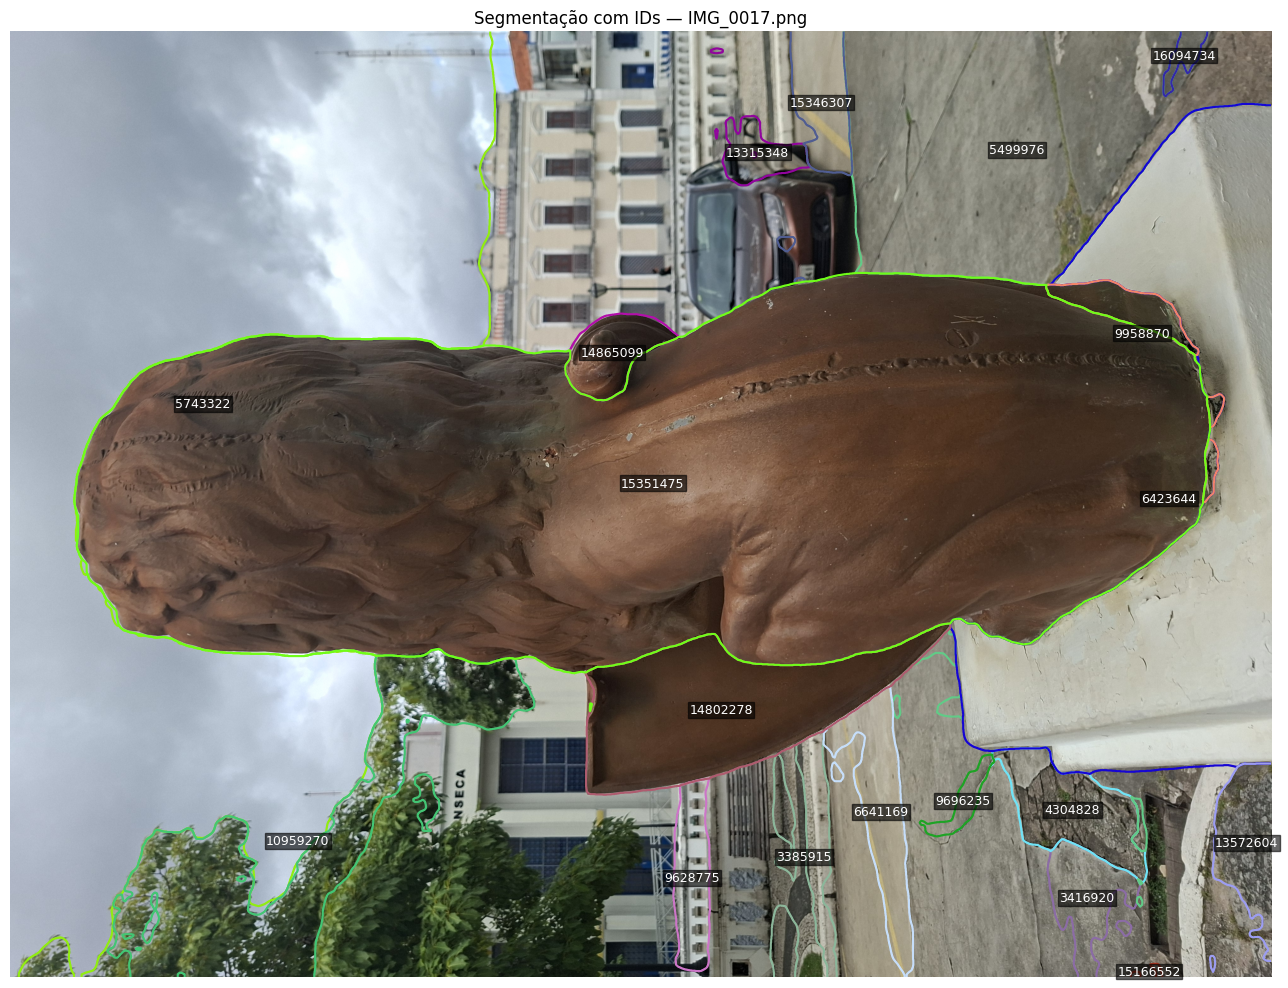

In [16]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import os

ann_dir = f"{SCENE_DIR}/deva_output/Annotations"
frames = sorted(os.listdir(ann_dir))
frame_name = frames[len(frames)//2]  # um frame do meio como amostra

mask_rgb = np.array(Image.open(os.path.join(ann_dir, frame_name)).convert("RGB"))
ids_decoded = (mask_rgb[:,:,0].astype(np.int64)
               + mask_rgb[:,:,1].astype(np.int64) * 256
               + mask_rgb[:,:,2].astype(np.int64) * 256 * 256)
unique_ids = np.unique(ids_decoded)

img_name = frame_name.replace(".png", ".jpg")
rgb_path = os.path.join(input_path, img_name)
rgb_img = np.array(Image.open(rgb_path).convert("RGB"))

fig, ax = plt.subplots(1, 1, figsize=(14, 10))
ax.imshow(rgb_img)
np.random.seed(0)
for oid in unique_ids:
    if oid == 0:
        continue
    mask = (ids_decoded == oid)
    ys, xs = np.where(mask)
    if len(xs) == 0:
        continue
    cx, cy = int(xs.mean()), int(ys.mean())
    color = np.random.rand(3,)
    ax.contour(mask, colors=[color], linewidths=1.5)
    ax.text(cx, cy, str(oid), color="white", fontsize=9, ha="center", va="center",
            bbox=dict(facecolor="black", alpha=0.6, pad=1))
ax.set_title(f"Segmentação com IDs — {frame_name}")
ax.axis("off")
plt.tight_layout()
plt.show()

Anote os IDs (números nos rótulos brancos) do(s) objeto(s) que você quer remover/inpaintar e coloque em `TARGET_IDS` abaixo.

In [17]:
import numpy as np
from PIL import Image
import os, shutil

TARGET_IDS = [15351475, 14802278]  # <-- ajuste com os IDs do objeto a remover
factor = 2

img_dir = f"{SCENE_DIR}/images_{factor}"
original_img_dir = f"{SCENE_DIR}/images"

if os.path.exists(img_dir):
    shutil.rmtree(img_dir)
os.makedirs(img_dir, exist_ok=True)

print(f"Populating {img_dir} with downscaled images from {original_img_dir}...")
original_image_files = sorted([f for f in os.listdir(original_img_dir)
                                if f.lower().endswith((".jpg", ".jpeg", ".png"))])
for orig_img_f in original_image_files:
    img = Image.open(os.path.join(original_img_dir, orig_img_f)).convert("RGB")
    w, h = img.size
    img_resized = img.resize((w // factor, h // factor), Image.LANCZOS)
    img_resized.save(os.path.join(img_dir, orig_img_f))
print(f"Populated {img_dir} with {len(original_image_files)} downscaled images.")

out_label_dir = f"{img_dir}/label"
os.makedirs(out_label_dir, exist_ok=True)

img_files = sorted([f for f in os.listdir(img_dir) if f.lower().endswith((".jpg", ".jpeg", ".png"))])
ann_files = sorted(os.listdir(ann_dir))
assert len(img_files) == len(ann_files), "Número de imagens e máscaras não bate"

for i, (img_f, ann_f) in enumerate(zip(img_files, ann_files)):
    mask_rgb = np.array(Image.open(os.path.join(ann_dir, ann_f)).convert("RGB"))
    ids_decoded = (mask_rgb[:,:,0].astype(np.int64)
                   + mask_rgb[:,:,1].astype(np.int64) * 256
                   + mask_rgb[:,:,2].astype(np.int64) * 256 * 256)
    binary = np.isin(ids_decoded, TARGET_IDS).astype(np.uint8) * 255
    target_size = Image.open(os.path.join(img_dir, img_f)).size
    mask_resized = Image.fromarray(binary).resize(target_size, Image.NEAREST)
    out_name = f"img{i:03d}.png"
    mask_resized.save(os.path.join(out_label_dir, out_name))

print(f"{len(os.listdir(out_label_dir))} máscaras salvas em {out_label_dir}")

Populating /content/data/images_2 with downscaled images from /content/data/images...
Populated /content/data/images_2 with 33 downscaled images.
33 máscaras salvas em /content/data/images_2/label


## 4. Checkpoint do LaMa + Passo A — NeRF inicial (extração de profundidade)

In [18]:
%cd /content/SPIn-NeRF/lama
# Checkpoint oficial do LaMa (Big LaMa)
!curl -L -o big-lama.zip 'https://huggingface.co/smartywu/big-lama/resolve/main/big-lama.zip' \
    || echo "Se este link falhar, baixe manualmente em https://github.com/advimman/lama"
!unzip -oq big-lama.zip -d .
!ls big-lama

/content/SPIn-NeRF/lama
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  1052  100  1052    0     0  10687      0 --:--:-- --:--:-- --:--:-- 10734
100  363M  100  363M    0     0  37.1M      0  0:00:09  0:00:09 --:--:-- 43.7M
config.yaml  models


In [19]:
# Instala o tiny-cuda-nn (necessário porque run_nerf.py importa ele incondicionalmente,
# mesmo quando o config usado não é o backbone grid-based)
!apt-get -qq install -y build-essential
!pip install -q ninja

import subprocess, os
cc = subprocess.check_output(
    ["nvidia-smi", "--query-gpu=compute_cap", "--format=csv,noheader"]
).decode().strip().replace(".", "")
os.environ["TCNN_CUDA_ARCHITECTURES"] = cc
print("GPU compute capability detectada:", cc)

!pip install -q git+https://github.com/NVlabs/tiny-cuda-nn/#subdirectory=bindings/torch

# tkinter também é importado pelo run_nerf.py — garante que está disponível
!apt-get -qq install -y python3-tk

GPU compute capability detectada: 120
  Preparing metadata (setup.py) ... done


In [20]:
%cd /content/SPIn-NeRF
# Mostra todas as ocorrências antes de corrigir (só para conferência)
!grep -rn "ignoregamma" --include="*.py" .

# Remove o argumento ignoregamma=True em todos os arquivos .py do repo
# (incompatível com versões recentes do imageio)
!find . -name "*.py" -exec sed -i 's/, ignoregamma=True//g; s/ignoregamma=True//g' {} +

# Confirma que não sobrou nada
!grep -rn "ignoregamma" --include="*.py" . || echo "Nenhuma ocorrencia restante - corrigido."

/content/SPIn-NeRF
Nenhuma ocorrencia restante - corrigido.


In [21]:
import os

expname = SCENE_NAME
datadir = SCENE_DIR      # <-- CORRIGIDO: antes era "/content/data/deva_output"
factor = 2

if not os.path.exists('/content/SPIn-NeRF'):
    %cd /content
    !git clone https://github.com/spinnerf3d/SPIn-NeRF.git
    print("Cloned SPIn-NeRF repository as it was missing.")
else:
    print("SPIn-NeRF repository already exists at /content/SPIn-NeRF.")

# Limpa saídas de execuções anteriores (idempotência)
!mkdir -p /content/SPIn-NeRF/lama/LaMa_test_images /content/SPIn-NeRF/lama/output/label
!rm -rf /content/SPIn-NeRF/lama/LaMa_test_images/*
!rm -rf /content/SPIn-NeRF/lama/output/label/*

# Confirma que os pré-requisitos existem antes de rodar
assert os.path.exists(f"{datadir}/poses_bounds.npy"), \
    "poses_bounds.npy ausente — rode a célula do imgs2poses.py (Seção 2) antes desta."

!cd /content/SPIn-NeRF && python DS_NeRF/run_nerf.py --config DS_NeRF/configs/config.txt \
    --render_factor 1 --prepare \
    --i_weight 1000000000 --i_video 1000000000 --i_feat 4000 --N_iters 4001 \
    --expname {expname} --datadir {datadir} --factor {factor} --N_gt 0

SPIn-NeRF repository already exists at /content/SPIn-NeRF.
2026-07-08 19:23:41.782086: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-08 19:23:41.814666: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/content/SPIn-NeRF/DS_NeRF/activation.py:7: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @custom_fwd(cast_inputs=torch.float)
/content/SPIn-NeRF/DS_NeRF/activation.py:13: FutureWarning: `torch.cuda.

## 5. Passo B — LaMa: inpainting das disparidades/profundidade

Correções de compatibilidade no código do LaMa (versões novas de `albumentations` e `kornia` quebraram alguns imports; `torch.load` passou a exigir `weights_only=False` explicitamente para checkpoints antigos). Cada célula é idempotente — se já rodou antes, o `assert` avisa em vez de quebrar.

In [23]:
path = "/content/SPIn-NeRF/lama/saicinpainting/training/data/aug.py"
with open(path, "r") as f:
    content = f.read()

old_header = "from albumentations import DualIAATransform, to_tuple\nimport imgaug.augmenters as iaa"
new_header = (
    "from albumentations import to_tuple\n"
    "from albumentations.core.transforms_interface import DualTransform\n\n\n"
    "class DualIAATransform(DualTransform):\n"
    "    \"\"\"Shim de compatibilidade: versões recentes do albumentations removeram\n"
    "    o DualIAATransform baseado em imgaug. Só existe aqui para as classes abaixo\n"
    "    continuarem importáveis; o 'processor' (imgaug) é carregado sob demanda e\n"
    "    não é usado no caminho de inferência (bin/predict.py).\"\"\"\n"
    "    pass"
)

if old_header in content:
    content = content.replace(old_header, new_header)
    with open(path, "w") as f:
        f.write(content)
    print("aug.py corrigido com sucesso.")
else:
    print("Cabeçalho já corrigido anteriormente (idempotente).")

Cabeçalho já corrigido anteriormente (idempotente).


In [24]:
path = "/content/SPIn-NeRF/lama/saicinpainting/training/data/aug.py"
with open(path, "r") as f:
    content = f.read()

old_header = "from albumentations import to_tuple\nfrom albumentations.core.transforms_interface import DualTransform"
new_header = (
    "from albumentations.core.utils import to_tuple\n"
    "from albumentations.core.transforms_interface import DualTransform"
)

if old_header in content:
    content = content.replace(old_header, new_header)
    with open(path, "w") as f:
        f.write(content)
    print("aug.py corrigido (to_tuple) com sucesso.")
else:
    print("Já corrigido anteriormente (idempotente).")

!head -n 10 /content/SPIn-NeRF/lama/saicinpainting/training/data/aug.py

Já corrigido anteriormente (idempotente).
from albumentations.core.utils import to_tuple
from albumentations.core.transforms_interface import DualTransform


class DualIAATransform(DualTransform):
    """Shim de compatibilidade: versões recentes do albumentations removeram
    o DualIAATransform baseado em imgaug. Só existe aqui para as classes abaixo
    continuarem importáveis; o 'processor' (imgaug) é carregado sob demanda e
    não é usado no caminho de inferência (bin/predict.py)."""
    pass


In [25]:
path = "/content/SPIn-NeRF/lama/saicinpainting/training/modules/fake_fakes.py"
with open(path, "r") as f:
    content = f.read()

old = "from kornia import SamplePadding"
new = "from kornia.constants import SamplePadding"

if old in content:
    content = content.replace(old, new)
    with open(path, "w") as f:
        f.write(content)
    print("fake_fakes.py corrigido com sucesso.")
else:
    print("Já corrigido anteriormente (idempotente).")

Já corrigido anteriormente (idempotente).


In [26]:
path = "/content/SPIn-NeRF/lama/saicinpainting/training/trainers/__init__.py"
with open(path, "r") as f:
    content = f.read()

old = "state = torch.load(path, map_location=map_location)"
new = "state = torch.load(path, map_location=map_location, weights_only=False)"

if old in content:
    content = content.replace(old, new)
    with open(path, "w") as f:
        f.write(content)
    print("trainers/__init__.py corrigido com sucesso.")
else:
    print("Já corrigido anteriormente (idempotente).")

Já corrigido anteriormente (idempotente).


In [27]:
%cd /content/SPIn-NeRF/lama
import os
os.environ["TORCH_HOME"] = os.getcwd()
os.environ["PYTHONPATH"] = os.getcwd()

n_imgs = len(os.listdir("LaMa_test_images")) if os.path.exists("LaMa_test_images") else 0
assert n_imgs > 0, "LaMa_test_images está vazia — confira se o Passo A (Seção 4) rodou com sucesso."
print(f"{n_imgs} arquivos em LaMa_test_images, prosseguindo com o inpainting de profundidade.")

!python bin/predict.py refine=True model.path=$(pwd)/big-lama \
    indir=$(pwd)/LaMa_test_images outdir=$(pwd)/output

/content/SPIn-NeRF/lama
34 arquivos em LaMa_test_images, prosseguindo com o inpainting de profundidade.
Detectron v2 is not installed
/content/SPIn-NeRF/lama/bin/predict.py:38: UserWarning: 
The version_base parameter is not specified.
Please specify a compatability version level, or None.
Will assume defaults for version 1.1
  @hydra.main(config_path='../configs/prediction', config_name='default.yaml')
/usr/local/lib/python3.12/dist-packages/hydra/_internal/hydra.py:119: UserWarning: Future Hydra versions will no longer change working directory at job runtime by default.
See https://hydra.cc/docs/1.2/upgrades/1.1_to_1.2/changes_to_job_working_dir/ for more information.
  ret = run_job(
[2026-07-08 19:34:16,630][saicinpainting.utils][WARNING] - Setting signal 10 handler <function print_traceback_handler at 0x7a8067bd8fe0>
[2026-07-08 19:34:16,638][root][INFO] - Make training model default
[2026-07-08 19:34:16,638][saicinpainting.training.trainers.base][INFO] - BaseInpaintingTrainingMod

In [ ]:
!ls -la /content/SPIn-NeRF/lama/output/label | head -20

In [28]:
%cd /content/SPIn-NeRF
dataset = SCENE_NAME
factor = 2
!rm -rf {SCENE_DIR}/images_{factor}/depth
!mkdir -p {SCENE_DIR}/images_{factor}/depth
!cp lama/output/label/*.png {SCENE_DIR}/images_{factor}/depth

/content/SPIn-NeRF


In [29]:
!grep -n "N_gt" /content/SPIn-NeRF/DS_NeRF/run_nerf.py
!grep -n "N_gt\|gt_img\|ground.truth\|gt_pose" /content/SPIn-NeRF/DS_NeRF/load_llff.py
!grep -n "N_gt" /content/SPIn-NeRF/DS_NeRF/llff/poses/pose_utils.py 2>/dev/null

903:    parser.add_argument("--N_gt", type=int, default=0,
1030:        if args.N_gt > 0:
1032:                i_test = i_train[:args.N_gt]
1034:                    i_train = i_train[args.N_gt:]
1036:                    i_train = i_train[args.N_gt:args.N_gt + args.N_train]
1039:                i_train = i_train[:args.N_gt]


## 6. Passo C — LaMa: inpainting das imagens RGB

Mesmo padrão do Passo B, mas aplicado às imagens RGB em vez das profundidades.

In [31]:
%cd /content/SPIn-NeRF/lama
import os, shutil

dataset = SCENE_NAME
factor = 2

!rm -rf LaMa_test_images/*
!rm -rf output/*

img_src_dir = f"{SCENE_DIR}/images_{factor}"
mask_src_dir = f"{SCENE_DIR}/images_{factor}/label"
os.makedirs("LaMa_test_images", exist_ok=True)

img_files = sorted([f for f in os.listdir(img_src_dir) if f.lower().endswith((".jpg", ".jpeg", ".png"))])
mask_files = sorted([f for f in os.listdir(mask_src_dir) if f.lower().endswith(".png")])

assert len(img_files) == len(mask_files), \
    f"Quantidade não bate: {len(img_files)} imagens vs {len(mask_files)} máscaras"

n_copied = 0
for img_f, mask_f in zip(img_files, mask_files):
    stem, ext = os.path.splitext(img_f)
    # imagem
    shutil.copy(os.path.join(img_src_dir, img_f), os.path.join("LaMa_test_images", img_f))
    # máscara no formato que o LaMa espera: <stem_da_imagem>_mask001<ext_da_imagem>
    shutil.copy(os.path.join(mask_src_dir, mask_f), os.path.join("LaMa_test_images", f"{stem}_mask001{ext}"))
    n_copied += 1
    if n_copied <= 3:
        print(f"  {img_f}  <->  {mask_f}  ->  {stem}_mask001{ext}")

print(f"{n_copied} pares imagem+máscara prontos em LaMa_test_images")
assert n_copied > 0

!python bin/predict.py refine=True model.path=$(pwd)/big-lama \
    indir=$(pwd)/LaMa_test_images outdir=$(pwd)/output

/content/SPIn-NeRF/lama
  IMG_0001.jpg  <->  img000.png  ->  IMG_0001_mask001.jpg
  IMG_0002.jpg  <->  img001.png  ->  IMG_0002_mask001.jpg
  IMG_0003.jpg  <->  img002.png  ->  IMG_0003_mask001.jpg
33 pares imagem+máscara prontos em LaMa_test_images
Detectron v2 is not installed
/content/SPIn-NeRF/lama/bin/predict.py:38: UserWarning: 
The version_base parameter is not specified.
Please specify a compatability version level, or None.
Will assume defaults for version 1.1
  @hydra.main(config_path='../configs/prediction', config_name='default.yaml')
/usr/local/lib/python3.12/dist-packages/hydra/_internal/hydra.py:119: UserWarning: Future Hydra versions will no longer change working directory at job runtime by default.
See https://hydra.cc/docs/1.2/upgrades/1.1_to_1.2/changes_to_job_working_dir/ for more information.
  ret = run_job(
[2026-07-08 19:39:57,325][saicinpainting.utils][WARNING] - Setting signal 10 handler <function print_traceback_handler at 0x7b2f41567ec0>
[2026-07-08 19:39:57

In [34]:
%cd /content/SPIn-NeRF/lama
import os, shutil
from PIL import Image

dataset = SCENE_NAME
factor = 2

!rm -rf LaMa_test_images/*
!rm -rf output/*

img_src_dir = f"{SCENE_DIR}/images_{factor}"
mask_src_dir = f"{SCENE_DIR}/images_{factor}/label"
os.makedirs("LaMa_test_images", exist_ok=True)

img_files = sorted([f for f in os.listdir(img_src_dir) if f.lower().endswith((".jpg", ".jpeg", ".png"))])
mask_files = sorted([f for f in os.listdir(mask_src_dir) if f.lower().endswith(".png")])

assert len(img_files) == len(mask_files), \
    f"Quantidade não bate: {len(img_files)} imagens vs {len(mask_files)} máscaras"

n_copied = 0
for img_f, mask_f in zip(img_files, mask_files):
    stem = os.path.splitext(img_f)[0]

    # imagem: reabre e resalva como PNG de verdade (não só renomeia)
    img = Image.open(os.path.join(img_src_dir, img_f)).convert("RGB")
    img.save(os.path.join("LaMa_test_images", f"{stem}.png"))

    # máscara: já é PNG, só copia
    shutil.copy(os.path.join(mask_src_dir, mask_f), os.path.join("LaMa_test_images", f"{stem}_mask001.png"))

    n_copied += 1
    if n_copied <= 3:
        print(f"  {img_f}  <->  {mask_f}  ->  {stem}.png + {stem}_mask001.png")

print(f"{n_copied} pares imagem+máscara prontos em LaMa_test_images (tudo .png)")
assert n_copied > 0

!ls LaMa_test_images | head -10
!echo "Total de arquivos:" && ls LaMa_test_images | wc -l

# roda SEM overrides de img_suffix — usa o default .png, que é o que já funcionou no Passo B
!python bin/predict.py refine=True model.path=$(pwd)/big-lama \
    indir=$(pwd)/LaMa_test_images outdir=$(pwd)/output

/content/SPIn-NeRF/lama
  IMG_0001.jpg  <->  img000.png  ->  IMG_0001.png + IMG_0001_mask001.png
  IMG_0002.jpg  <->  img001.png  ->  IMG_0002.png + IMG_0002_mask001.png
  IMG_0003.jpg  <->  img002.png  ->  IMG_0003.png + IMG_0003_mask001.png
33 pares imagem+máscara prontos em LaMa_test_images (tudo .png)
IMG_0001_mask001.png
IMG_0001.png
IMG_0002_mask001.png
IMG_0002.png
IMG_0003_mask001.png
IMG_0003.png
IMG_0004_mask001.png
IMG_0004.png
IMG_0005_mask001.png
IMG_0005.png
Total de arquivos:
66
Detectron v2 is not installed
/content/SPIn-NeRF/lama/bin/predict.py:38: UserWarning: 
The version_base parameter is not specified.
Please specify a compatability version level, or None.
Will assume defaults for version 1.1
  @hydra.main(config_path='../configs/prediction', config_name='default.yaml')
/usr/local/lib/python3.12/dist-packages/hydra/_internal/hydra.py:119: UserWarning: Future Hydra versions will no longer change working directory at job runtime by default.
See https://hydra.cc/docs/

In [35]:
import os
d = "/content/SPIn-NeRF/lama/LaMa_test_images"
files = sorted(os.listdir(d)) if os.path.exists(d) else None
print("Pasta existe?", os.path.exists(d))
print("Total de arquivos:", len(files) if files else 0)
print("Primeiros 10:", files[:10] if files else None)

Pasta existe? True
Total de arquivos: 66
Primeiros 10: ['IMG_0001.png', 'IMG_0001_mask001.png', 'IMG_0002.png', 'IMG_0002_mask001.png', 'IMG_0003.png', 'IMG_0003_mask001.png', 'IMG_0004.png', 'IMG_0004_mask001.png', 'IMG_0005.png', 'IMG_0005_mask001.png']


In [36]:
!cat /content/SPIn-NeRF/lama/saicinpainting/evaluation/data.py

import glob
import os

import cv2
import PIL.Image as Image
import numpy as np

from torch.utils.data import Dataset
import torch.nn.functional as F


def load_image(fname, mode='RGB', return_orig=False):
    img = np.array(Image.open(fname).convert(mode))
    if img.ndim == 3:
        img = np.transpose(img, (2, 0, 1))
    out_img = img.astype('float32') / 255
    if return_orig:
        return out_img, img
    else:
        return out_img


def ceil_modulo(x, mod):
    if x % mod == 0:
        return x
    return (x // mod + 1) * mod


def pad_img_to_modulo(img, mod):
    channels, height, width = img.shape
    out_height = ceil_modulo(height, mod)
    out_width = ceil_modulo(width, mod)
    return np.pad(img, ((0, 0), (0, out_height - height), (0, out_width - width)), mode='symmetric')


def pad_tensor_to_modulo(img, mod):
    batch_size, channels, height, width = img.shape
    out_height = ceil_modulo(height, mod)
    out_width = ceil_modulo(width, mod)
    return F.pad(img, pad=(0

In [40]:
%cd /content/SPIn-NeRF/lama
import os, shutil, sys
from PIL import Image

factor = 2
img_src_dir = f"{SCENE_DIR}/images_{factor}"
mask_src_dir = f"{SCENE_DIR}/images_{factor}/label"

# 1. Limpa tudo do zero
root = "/content/SPIn-NeRF/lama/LaMa_test_images"
if os.path.exists(root):
    shutil.rmtree(root)
os.makedirs(os.path.join(root, "label"), exist_ok=True)
shutil.rmtree("output", ignore_errors=True)

# 2. Prepara: imagens .png na raiz, máscaras .png em label/
img_files = sorted([f for f in os.listdir(img_src_dir)
                     if f.lower().endswith((".jpg", ".jpeg", ".png"))
                     and os.path.isfile(os.path.join(img_src_dir, f))])
mask_files = sorted([f for f in os.listdir(mask_src_dir) if f.lower().endswith(".png")])

assert len(img_files) == len(mask_files), \
    f"Contagem não bate: {len(img_files)} imagens vs {len(mask_files)} máscaras"

for img_f in img_files:
    stem = os.path.splitext(img_f)[0]
    Image.open(os.path.join(img_src_dir, img_f)).convert("RGB").save(
        os.path.join(root, f"{stem}.png")
    )
for mask_f in mask_files:
    shutil.copy(os.path.join(mask_src_dir, mask_f), os.path.join(root, "label", mask_f))

print("Conteúdo da raiz:", sorted(os.listdir(root))[:6])
print("Conteúdo de label/:", sorted(os.listdir(os.path.join(root, "label")))[:6])

# 3. Testa o dataset isoladamente ANTES de gastar tempo com predict.py
sys.path.insert(0, ".")
from saicinpainting.training.data.datasets import make_default_val_dataset
dataset = make_default_val_dataset(root + "/", kind="default", img_suffix=".png")
print("Tamanho do dataset:", len(dataset))
assert len(dataset) > 0, "Dataset ainda vazio — pare aqui e me manda os prints acima"

# 4. Só roda o LaMa se o teste acima passou
!python bin/predict.py refine=True model.path=$(pwd)/big-lama \
    indir=$(pwd)/LaMa_test_images outdir=$(pwd)/output

/content/SPIn-NeRF/lama
Conteúdo da raiz: ['IMG_0001.png', 'IMG_0002.png', 'IMG_0003.png', 'IMG_0004.png', 'IMG_0005.png', 'IMG_0006.png']
Conteúdo de label/: ['img000.png', 'img001.png', 'img002.png', 'img003.png', 'img004.png', 'img005.png']
Tamanho do dataset: 33
Detectron v2 is not installed
/content/SPIn-NeRF/lama/bin/predict.py:38: UserWarning: 
The version_base parameter is not specified.
Please specify a compatability version level, or None.
Will assume defaults for version 1.1
  @hydra.main(config_path='../configs/prediction', config_name='default.yaml')
/usr/local/lib/python3.12/dist-packages/hydra/_internal/hydra.py:119: UserWarning: Future Hydra versions will no longer change working directory at job runtime by default.
See https://hydra.cc/docs/1.2/upgrades/1.1_to_1.2/changes_to_job_working_dir/ for more information.
  ret = run_job(
[2026-07-08 19:54:04,961][saicinpainting.utils][WARNING] - Setting signal 10 handler <function print_traceback_handler at 0x7c32d63c7ec0>
[20

In [41]:
%cd /content/SPIn-NeRF/lama
!mkdir -p {SCENE_DIR}/images_{factor}/lama_images
!cp {SCENE_DIR}/images_{factor}/*.png {SCENE_DIR}/images_{factor}/lama_images 2>/dev/null
!cp ./output/label/*.png {SCENE_DIR}/images_{factor}/lama_images/

/content/SPIn-NeRF/lama


## 7. Passo D — Fitting final do NeRF inpainted

In [42]:
import sys, os
sys.path.insert(0, "/content/SPIn-NeRF/DS_NeRF")
from load_llff import load_colmap_depth, _load_data
import numpy as np

factor = 2
depth_gts = load_colmap_depth(SCENE_DIR, factor=factor, bd_factor=.75)
_, _, imgs, masks, _, _ = _load_data(SCENE_DIR, factor=factor)
masks = np.moveaxis(masks, -1, 0).squeeze().astype(np.float32)
masks = masks / np.max(masks)  # mesma normalização usada no load_llff_data

total_pts, total_kept = 0, 0
for i in range(len(depth_gts)):
    coords = depth_gts[i]['coord']
    kept = 0
    for c in coords:
        y = min(int(c[1]), masks[i].shape[0]-1)
        x = min(int(c[0]), masks[i].shape[1]-1)
        if masks[i][y][x] == 0:
            kept += 1
    total_pts += len(coords)
    total_kept += kept
    print(f"img {i:02d}: {len(coords)} pontos COLMAP, {kept} sobrevivem à máscara ({100*kept/max(len(coords),1):.1f}%)")

print(f"\nTOTAL: {total_pts} pontos, {total_kept} sobrevivem no total")
print(f"Cobertura média da máscara sobre a área da imagem: {100*np.mean(masks):.1f}%")

Mean Projection Error: 1.2268122074783192
(1500, 2000)
(1161, 1549)
(1500, 2000)
(1161, 1549)
(1500, 2000)
(1161, 1549)
(1500, 2000)
(1161, 1549)
(1500, 2000)
(1161, 1549)
(1500, 2000)
(1161, 1549)
(1500, 2000)
(1161, 1549)
(1500, 2000)
(1161, 1549)
(1500, 2000)
(1161, 1549)
(1500, 2000)
(1161, 1549)
(1500, 2000)
(1161, 1549)
(1500, 2000)
(1161, 1549)
(1500, 2000)
(1161, 1549)
(1500, 2000)
(1161, 1549)
(1500, 2000)
(1161, 1549)
(1500, 2000)
(1161, 1549)
(1500, 2000)
(1161, 1549)
(1500, 2000)
(1161, 1549)
(1500, 2000)
(1161, 1549)
(1500, 2000)
(1161, 1549)
(1500, 2000)
(1161, 1549)
(1500, 2000)
(1161, 1549)
(1500, 2000)
(1161, 1549)
(1500, 2000)
(1161, 1549)
(1500, 2000)
(1161, 1549)
(1500, 2000)
(1161, 1549)
(1500, 2000)
(1161, 1549)
(1500, 2000)
(1161, 1549)
(1500, 2000)
(1161, 1549)
(1500, 2000)
(1161, 1549)
(1500, 2000)
(1161, 1549)
(1500, 2000)
(1161, 1549)
(1500, 2000)
(1161, 1549)
Loaded image data (1161, 1549, 3, 33) [1161.         1549.         1427.86685024] (1161, 1549, 65)
n

In [43]:
import numpy as np
from PIL import Image
import glob, os

label_files = sorted(glob.glob(f"{SCENE_DIR}/images_{factor}/label/*.png"))
print(f"{len(label_files)} arquivos em label/")

for f in label_files:
    arr = np.array(Image.open(f).convert("L"))
    pct_branco = 100 * np.mean(arr > 127)
    print(f"{os.path.basename(f):20s} shape={arr.shape}  valores únicos={np.unique(arr)}  % marcado (objeto)={pct_branco:.1f}%")

33 arquivos em label/
img000.png           shape=(1500, 2000)  valores únicos=[  0 255]  % marcado (objeto)=18.0%
img001.png           shape=(1500, 2000)  valores únicos=[  0 255]  % marcado (objeto)=21.5%
img002.png           shape=(1500, 2000)  valores únicos=[  0 255]  % marcado (objeto)=19.8%
img003.png           shape=(1500, 2000)  valores únicos=[  0 255]  % marcado (objeto)=13.0%
img004.png           shape=(1500, 2000)  valores únicos=[  0 255]  % marcado (objeto)=18.5%
img005.png           shape=(1500, 2000)  valores únicos=[  0 255]  % marcado (objeto)=21.0%
img006.png           shape=(1500, 2000)  valores únicos=[  0 255]  % marcado (objeto)=18.4%
img007.png           shape=(1500, 2000)  valores únicos=[  0 255]  % marcado (objeto)=22.2%
img008.png           shape=(1500, 2000)  valores únicos=[  0 255]  % marcado (objeto)=26.6%
img009.png           shape=(1500, 2000)  valores únicos=[  0 255]  % marcado (objeto)=27.4%
img010.png           shape=(1500, 2000)  valores únicos=[ 

In [69]:
%cd /content/SPIn-NeRF
expname = SCENE_NAME
datadir = SCENE_DIR      # <-- CORRIGIDO: antes era "./data/statue"
factor = 2

assert os.path.exists(f"{datadir}/sparse/0/images.bin") or os.path.exists(f"{datadir}/poses_bounds.npy"), \
    "Dados de pose ausentes em datadir — confira as Seções 2 e 4."

!python DS_NeRF/run_nerf.py --config DS_NeRF/configs/config.txt \
    --i_feat 200 --lpips \
    --i_weight 1000000000000 --i_video 1000 --N_iters 10001 \
    --expname {expname} --datadir {datadir} --N_gt 0 --factor {factor}

/content/SPIn-NeRF
2026-07-08 22:15:44.695438: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-08 22:15:44.727815: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/content/SPIn-NeRF/DS_NeRF/activation.py:7: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @custom_fwd(cast_inputs=torch.float)
/content/SPIn-NeRF/DS_NeRF/activation.py:13: FutureWarning: `torch.cuda.amp.custom_bwd(args...)` is deprecated. 

## 8. Visualização do vídeo renderizado

In [47]:
from IPython.display import Video
import glob

videos = sorted(glob.glob(f"logs/{SCENE_NAME}/*_test.mp4"))
print(videos)
if videos:
    display(Video(videos[-1], embed=True, width=640))
else:
    print("Nenhum vídeo encontrado ainda — confira se o Passo D concluiu as iterações de --i_video.")

['logs/statue/statue_lpips_True_prepare_False_001000_test.mp4', 'logs/statue/statue_lpips_True_prepare_False_002000_test.mp4', 'logs/statue/statue_lpips_True_prepare_False_003000_test.mp4', 'logs/statue/statue_lpips_True_prepare_False_004000_test.mp4', 'logs/statue/statue_lpips_True_prepare_False_005000_test.mp4', 'logs/statue/statue_lpips_True_prepare_False_006000_test.mp4', 'logs/statue/statue_lpips_True_prepare_False_007000_test.mp4', 'logs/statue/statue_lpips_True_prepare_False_008000_test.mp4', 'logs/statue/statue_lpips_True_prepare_False_009000_test.mp4', 'logs/statue/statue_lpips_True_prepare_False_010000_test.mp4']


In [48]:
from google.colab import files
if videos:
    files.download(videos[-1])

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [70]:
# rodar depois do treino do Passo D, no Colab
import os, glob, numpy as np
from PIL import Image
import lpips
import torch
from skimage.metrics import structural_similarity as ssim_fn
from skimage.metrics import peak_signal_noise_ratio as psnr_fn

SCENE_DIR = "/content/data"
factor = 2
# Atualizado render_dir para apontar para o diretório correto onde as imagens renderizadas são salvas com --render_only --render_test
render_dir = f"logs/{SCENE_NAME}/renderonly_test_000000"
gt_dir = f"{SCENE_DIR}/images_{factor}"          # fotos originais (com objeto)
mask_dir = f"{SCENE_DIR}/images_{factor}/label"  # máscaras binárias do objeto

loss_fn_alex = lpips.LPIPS(net='alex')

renders = sorted(glob.glob(f"{render_dir}/*.png"))
psnrs, ssims, lpipss = [], [], []

for r_path in renders:
    name = os.path.basename(r_path)
    # Assume que os nomes de arquivo dos renders são 000.png, 001.png, etc.
    # e correspondem diretamente aos imgXXX.png nas máscaras e IMG_XXXX.jpg nos GTs.
    # Precisamos converter 000.png para IMG_0001.jpg para o GT, e img000.png para a máscara.
    idx = int(name.split('.')[0]) # Extrai o índice numérico (ex: 0 para 000.png)
    gt_name = sorted([f for f in os.listdir(gt_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])[idx]
    gt_path = os.path.join(gt_dir, gt_name)
    mask_name = sorted(os.listdir(mask_dir))[idx]
    mask_path = os.path.join(mask_dir, mask_name)

    if not (os.path.exists(gt_path) and os.path.exists(mask_path)):
        print(f"Skipping {name}: GT or mask not found (GT: {gt_path}, Mask: {mask_path})")
        continue

    render = np.array(Image.open(r_path).convert("RGB")).astype(np.float32) / 255.0
    gt = np.array(Image.open(gt_path).convert("RGB").resize(render.shape[1::-1])).astype(np.float32) / 255.0
    mask = np.array(Image.open(mask_path).convert("L").resize(render.shape[1::-1])) > 127  # True = objeto (ignorar)

    keep = ~mask
    if keep.sum() == 0:
        continue

    # PSNR/SSIM só na região válida (fora do objeto)
    mse = np.mean((render[keep] - gt[keep]) ** 2)
    psnr = 10 * np.log10(1.0 / (mse + 1e-8))
    s = ssim_fn(render, gt, channel_axis=2, data_range=1.0)  # SSIM full-image (aprox)

    # LPIPS espera tensores [-1,1], NCHW
    r_t = torch.from_numpy(render).permute(2,0,1).unsqueeze(0) * 2 - 1
    g_t = torch.from_numpy(gt).permute(2,0,1).unsqueeze(0) * 2 - 1
    l = loss_fn_alex(r_t, g_t).item()

    psnrs.append(psnr); ssims.append(s); lpipss.append(l)
    print(f"{name}: PSNR={psnr:.2f}  SSIM={s:.3f}  LPIPS={l:.3f}")

if psnrs:
    print(f"\nMÉDIA (fora da máscara) — PSNR={np.mean(psnrs):.2f}  SSIM={np.mean(ssims):.3f}  LPIPS={np.mean(lpipss):.3f}")
else:
    print("Não foi possível calcular métricas: nenhum render válido encontrado ou correspondência com GT/máscaras.")

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth
Não foi possível calcular métricas: nenhum render válido encontrado ou correspondência com GT/máscaras.


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [71]:
import os

# Inspect the contents of the rendered output directory
output_dir = f"logs/{SCENE_NAME}/renderonly_test_000000"
print(f"Contents of {output_dir}:")
if os.path.exists(output_dir):
    for item in os.listdir(output_dir):
        print(f"- {item}")
else:
    print(f"Directory not found: {output_dir}")

Contents of logs/statue/renderonly_test_000000:
- intrinsics.txt
- rgb
- weight
- depth
- z
- disp
- rgb.mp4
- alpha
- disp.mp4
- pose
- images


A avaliação de métricas como PSNR, SSIM, e LPIPS espera um diretório com imagens PNG renderizadas individualmente. O treinamento do NeRF (Passo D) salvou os resultados como vídeos MP4. Precisamos extrair esses frames do vídeo e salvá-los como imagens PNG em um novo diretório.

In [ ]:
!python DS_NeRF/run_nerf.py --config DS_NeRF/configs/config.txt \
  --i_feat 200 --lpips \
  --i_weight 1000000000000 --i_video 1000 --N_iters 10001 \
  --expname statue_eval --datadir /content/data --N_gt 4 --factor 2

2026-07-08 22:22:59.732577: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-08 22:22:59.765068: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/content/SPIn-NeRF/DS_NeRF/activation.py:7: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @custom_fwd(cast_inputs=torch.float)
/content/SPIn-NeRF/DS_NeRF/activation.py:13: FutureWarning: `torch.cuda.amp.custom_bwd(args...)` is deprecated. Please use `torch.a

In [ ]:
import os, glob, csv
import numpy as np
from PIL import Image
import lpips
import torch
from skimage.metrics import structural_similarity as ssim_fn

SCENE_DIR = "/content/data"
factor = 2
render_dir = "/content/SPIn-NeRF/logs/statue_eval/renderonly_test_010000"  # ajuste
gt_dir = f"{SCENE_DIR}/images_{factor}"
mask_dir = f"{SCENE_DIR}/images_{factor}/label"
i_test_indices = [0, 8, 16, 24]  # os índices reais usados como teste (confira no log "TEST views are")

loss_fn_alex = lpips.LPIPS(net='alex')

gt_files = sorted([f for f in os.listdir(gt_dir) if f.lower().endswith((".jpg",".png"))])
mask_files = sorted(os.listdir(mask_dir))
render_files = sorted(glob.glob(f"{render_dir}/*.png"))

rows = []
for k, idx in enumerate(i_test_indices):
    render = np.array(Image.open(render_files[k]).convert("RGB")).astype(np.float32) / 255.0
    gt = np.array(Image.open(os.path.join(gt_dir, gt_files[idx])).convert("RGB").resize(render.shape[1::-1])).astype(np.float32) / 255.0
    mask = np.array(Image.open(os.path.join(mask_dir, mask_files[idx])).convert("L").resize(render.shape[1::-1])) > 127
    keep = ~mask

    mse = np.mean((render[keep] - gt[keep]) ** 2)
    psnr = 10 * np.log10(1.0 / (mse + 1e-8))
    s = ssim_fn(render, gt, channel_axis=2, data_range=1.0)
    r_t = torch.from_numpy(render).permute(2,0,1).unsqueeze(0) * 2 - 1
    g_t = torch.from_numpy(gt).permute(2,0,1).unsqueeze(0) * 2 - 1
    l = loss_fn_alex(r_t, g_t).item()

    rows.append({"pipeline": "SPIn-NeRF", "view_idx": idx, "psnr": psnr, "ssim": s, "lpips": l})
    print(rows[-1])

# salva num CSV único que vai acumular os resultados de TODOS os pipelines
csv_path = "/content/drive/MyDrive/eval_results.csv"  # ajuste pro seu Drive
write_header = not os.path.exists(csv_path)
with open(csv_path, "a", newline="") as f:
    w = csv.DictWriter(f, fieldnames=["pipeline", "view_idx", "psnr", "ssim", "lpips"])
    if write_header:
        w.writeheader()
    w.writerows(rows)

print(f"\nMédia SPIn-NeRF — PSNR={np.mean([r['psnr'] for r in rows]):.2f}  SSIM={np.mean([r['ssim'] for r in rows]):.3f}  LPIPS={np.mean([r['lpips'] for r in rows]):.3f}")

In [ ]:
import pandas as pd
df = pd.read_csv("/content/drive/MyDrive/eval_results.csv")
print(df.groupby("pipeline")[["psnr","ssim","lpips"]].mean())